# WILDFIRE RISK AND SEVERITY ANALYSIS

## BUSINESS UNDERSTANDING

### Project Problem Statement
Wildfires can cause serious damage to forests, property, and human life. Understanding the weather and environmental conditions that influence wildfire occurrence and severity can help improve preparation and response efforts to reduce wildfire risk and damage.

## Project Objective:
To explore environmental conditions that influence wildfire occurrence and severity. 

### Project Goal:
Understand how temperature, humidity, wind, and rainfall affect wildfire risk. 
Identify patterns that can support better wildfire preparedness and response.

## DATA UNDERSTANDING

Here, I explored the dataset to understand what it contains and check its quality before cleaning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading And Preview Of The Dataset 

In [4]:
df = pd.read_csv("../data/forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [3]:
df = pd.read_csv("../data/forestfires.csv")
df.tail()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00
516,6,3,nov,tue,79.5,3.0,106.7,1.1,11.8,31,4.5,0.0,0.00


In [7]:
df.shape

(517, 13)

#### Dataset Structure

In [6]:
df.dtypes

X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

#### Checking For Missing Values

In [5]:
df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

#### Understanding Variables In The Dataset

| Column | Meaning |
|---|---|
| X | x-axis spatial coordinate of the forest fire location |
| Y | y-axis spatial coordinate of the forest fire location |
| month | month the fire incident occurred |
| day | day of the week the fire incident occurred |
| FFMC | Fine Fuel Moisture Code- Tells how dry the surface materials are.  |
| DMC | Duff Moisture Code- measures the dryness in shallow soil layers |
| DC | Drought Code- measures long term drought conditions |
| ISI | Initial Spread Index- estimates how fast fire spreads after ignition. |
| temp | temperature in °C |
| RH | relative humidity (%) |
| wind | wind speed |
| rain | rainfall amount |
| area | burned forest area |

#### Data Overview

The dataset has 517 rows and 13 columns. It includes both categorical and numerical variables related to forest fire conditions, weather, and burned area.The dataset appears structured and suitable for analysis.

#### Dataset Observation

- The dataset is clean and well-structured.
- No missing values were found.
- Most variables are numerical.
- 'month' and 'day' are categorical variables.
- 'Burned area' appears to be the main variable of interest for analysis.

## DATA PREPARATION

Checking for duplicates

In [1]:
import pandas as pd
df = pd.read_csv("../data/forestfires.csv")
df.duplicated().sum()

np.int64(4)

In [8]:
# Displaying The Original and duplicated rows
df[df.duplicated(keep=False)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
52,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
99,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
214,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
302,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


#### Duplicate Check

A total of 4 duplicate rows were identified in the dataset. Since these rows were exact copies of existing records, they were removed to improve data quality and prevent duplicate observations from affecting the analysis.

In [9]:
# Removing duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
# Recomfirming For Missing Values

df.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [11]:
# Checking For Inconsistencies in Categorical Columns
# For Day
df["day"].unique()

array(['fri', 'tue', 'sat', 'sun', 'mon', 'wed', 'thu'], dtype=object)

In [12]:
# For Month
df["month"].unique()

array(['mar', 'oct', 'aug', 'sep', 'apr', 'jun', 'jul', 'feb', 'jan',
       'dec', 'may', 'nov'], dtype=object)

In [14]:
# Fixing Month Ordering
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

In [15]:
# Fixing Day Ordering
day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

df["day"] = pd.Categorical(df["day"], categories=day_order, ordered=True)

#### Checking Categorical Columns

I checked the categorical columns using their unique values to make sure there were no spelling or formatting issues. The month and day columns were consistent, so I converted them into ordered categories to keep their correct calendar order during analysis.

In [12]:
# Saving Copy of Cleaned Dataset
df_cleaned = df.copy()

#### Cleaned Dataset

A cleaned copy of the dataset was created and saved as "df_cleaned" for use in the next stage of analysis.

## Understanding The Target Variable

In this section, I examined the `area` column, which shows the total burned area caused by each fire. Since this is the value the model will predict, I checked its distribution and looked for extreme values before moving to modeling.

In [17]:
df['area'].describe()

count     513.000000
mean       12.891598
std        63.892586
min         0.000000
25%         0.000000
50%         0.540000
75%         6.570000
max      1090.840000
Name: area, dtype: float64

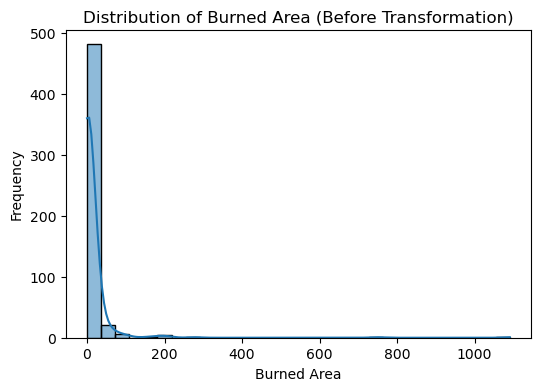

In [4]:
# Visualization of Target Variable
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['area'], bins=30, kde=True)
plt.title('Distribution of Burned Area (Before Transformation)')
plt.xlabel('Burned Area')
plt.ylabel('Frequency')
plt.show()

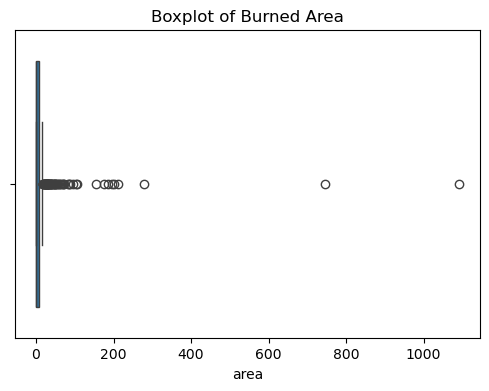

In [5]:
# Checking For Outliers (Extreme Values that deviate significantly from the rest of a dataset in a distribution)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['area'])
plt.title('Boxplot of Burned Area')
plt.show()

In [20]:
# Inspecting Skewness Of Burnt Area

df["area"].skew()

np.float64(12.802213419146321)

#### Skewness in Burned Area

The area column is heavily skewed to the right, with a skewness value of 12.80. This means most fires burned only small areas, while a few spread across much larger areas.

#### Burned Area Distribution Assessment

The burned area column was examined in more detail because it is the main variable being predicted in this project.

In [21]:
# Finding records with zero burned area
(df["area"] == 0).sum()

np.int64(244)

In [22]:
# Most frequent values in the area column
df["area"].value_counts().head()

area
0.00     244
1.94       3
1.46       2
9.96       2
11.06      2
Name: count, dtype: int64

#### Observation 

The burned area column contains many zero values, and most of the remaining values are relatively small compared to the few large ones.

#### Separation of Burned Area Into Groups

To better understand the nature of zero burned area records, the dataset is divided into:
- Fire events with no recorded burned area (`area = 0`)
- Fire events with measurable burned area (`area > 0`)

In [23]:
# Sectionining Of Area Column Into Groups
zero_area = df[df['area'] == 0]
non_zero_area = df[df['area'] > 0]

print("Zero area count:", len(zero_area))
print("Non-zero area count:", len(non_zero_area))

Zero area count: 244
Non-zero area count: 269


In [16]:
# Target Variable Log Transformation
import numpy as np

df_cleaned['area_log'] = np.log1p(df_cleaned['area'])

In [17]:
# Updating Cleaned Dataset With Newly added Column(area_log)

df_cleaned.to_csv('cleaned_forestfires.csv', index=False)

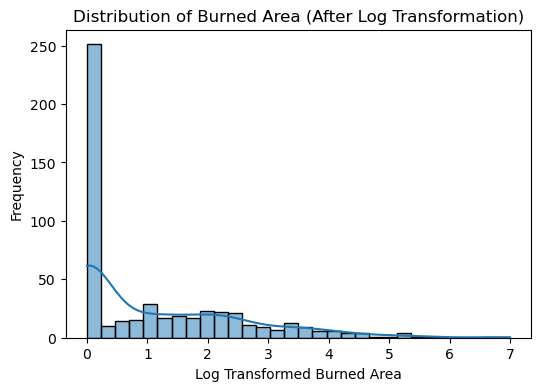

In [20]:
# Visualizing Transformed Target Variable

plt.figure(figsize=(6,4))
sns.histplot(df_cleaned['area_log'], bins=30, kde=True)
plt.title('Distribution of Burned Area (After Log Transformation)')
plt.xlabel('Log Transformed Burned Area')
plt.ylabel('Frequency')
plt.show()

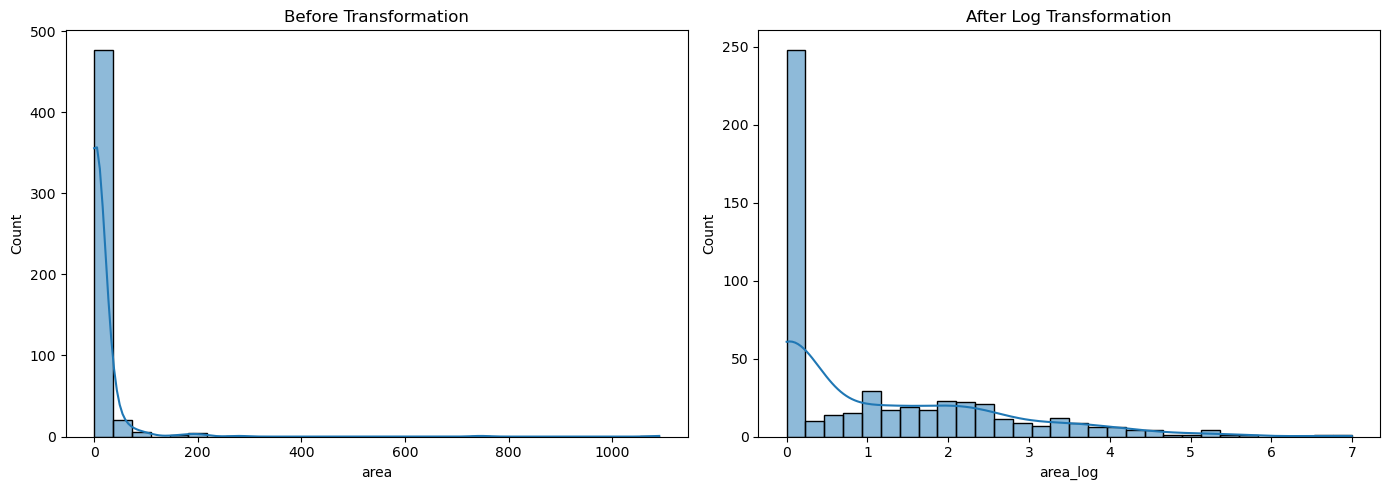

In [45]:
# Comparison of the before and after of the target Variable
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df['area'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Before Transformation')

sns.histplot(df_clean['area_log'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('After Log Transformation')

plt.tight_layout()
plt.show()

#### Preparing the Target Variable

The area column was heavily skewed, with many small values and a few very large ones. This made the distribution uneven and could affect model performance.

To reduce this skewness and limit the effect of extreme values, I applied a log transformation (log1p) to the area column.

This made the distribution more balanced and better suited for further analysis and modeling.

In [4]:
# LOADING UPDATED CLEANED DATASET

import pandas as pd

df_cleaned = pd.read_csv('cleaned_forestfires.csv')
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_log
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0


## EXPLORATORY DATA ANALYSIS

### Relationship Between Weather Variables and Fire Indices

This section looks at how environmental factors are related to fire weather indices. It is done to help understand the following questions:

Does temperature affect FFMC?
Does humidity Infuence DMC and reduce wildfire risk?
Does rainfall have an impact on DC and reset dryness?
Does wind speed Increase Fire spread (ISI)?

This is to see if these weather conditions have any relationship with fire behaviour, and to help with building a model that can predict whether a fire will be small or large.

Environmental_variables = ['temp', 'RH', 'rain', 'wind']
Fire_indices = ['FFMC', 'DMC', 'DC', 'ISI']

### Q1: Does Temperature(Heat) Affect FFMC

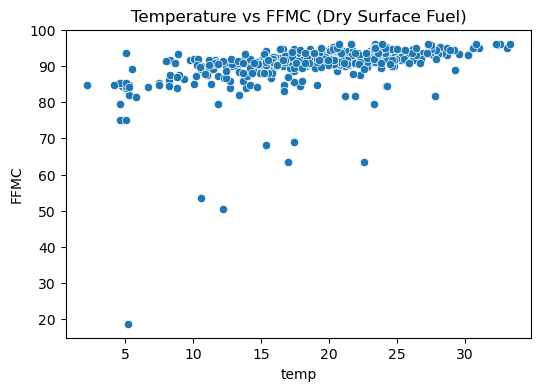

In [65]:
# Plotting Temperature Against FFMC
plt.figure(figsize=(6,4))
sns.scatterplot(x='temp', y='FFMC', data=df)
plt.title('Temperature vs FFMC (Dry Surface Fuel)')
plt.show()

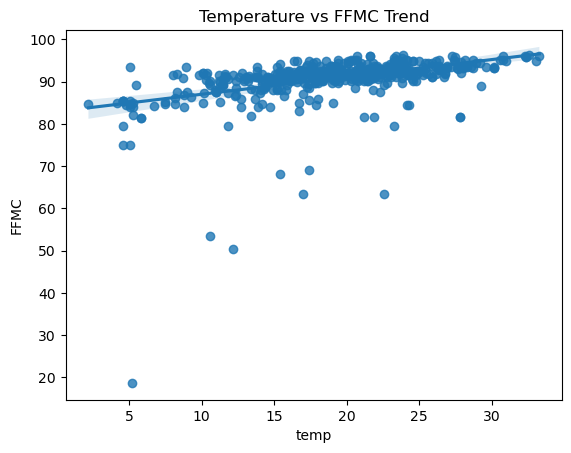

,temp,FFMC
temp,1.000000,0.431532
FFMC,0.431532,1.000000


In [64]:
# Adding Trend line
sns.regplot(x='temp', y='FFMC', data=df)
plt.title('Temperature vs FFMC Trend')
plt.show()

# Checking the correlation between the 2 variables
df[['temp', 'FFMC']].corr()

There is a moderate positive relationship (r = 0.43) between temperature and FFMC. This means that when temperature increases, FFMC also tends to increase. However, the relationship is not strong, as other weather factors like humidity, rainfall, and wind also play an important role in influencing FFMC.

### Q2: Does Relative humidity(Moisture in the air) Influence DMC?

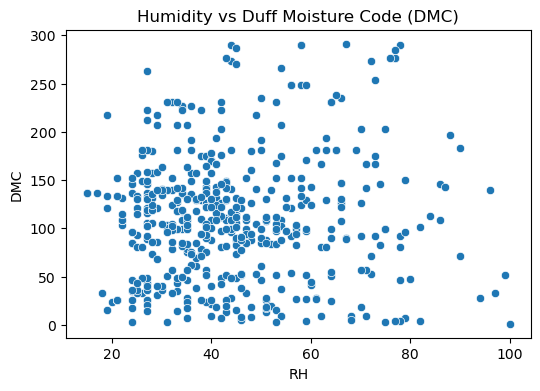

In [63]:
# Plotting Relative Humdity Against DMC
plt.figure(figsize=(6,4))
sns.scatterplot(x='RH', y='DMC', data=df)
plt.title('Humidity vs Duff Moisture Code (DMC)')
plt.show()

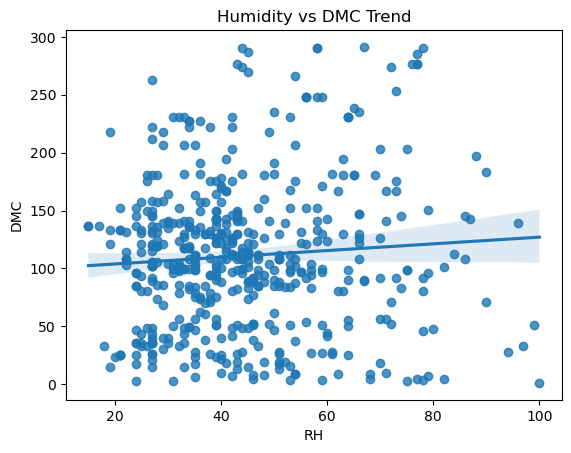

,RH,DMC
RH,1.000000,0.073795
DMC,0.073795,1.000000


In [62]:
# Adding Trend line
sns.regplot(x='RH', y='DMC', data=df)
plt.title("Humidity vs DMC Trend")
plt.show()

# Checking the correlation between the 2 variables
df[['RH', 'DMC']].corr()

### Q3: Does rainfall have an impact on DC and reset dryness?

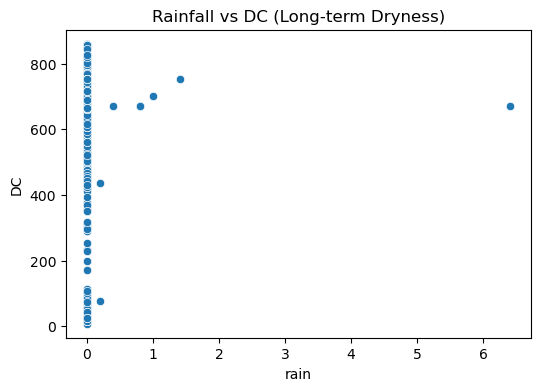

In [60]:
# Plotting Rainfall Against DC
plt.figure(figsize=(6,4))
sns.scatterplot(x='rain', y='DC', data=df)
plt.title('Rainfall vs DC (Long-term Dryness)')
plt.show()

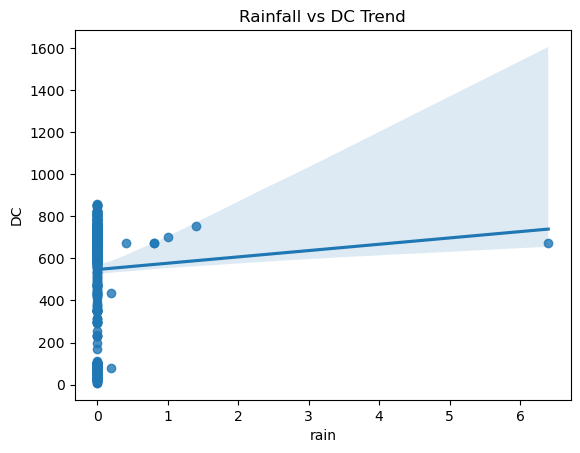

,rain,DC
rain,1.000000,0.035861
DC,0.035861,1.000000


In [66]:
# Adding Trend line
sns.regplot(x='rain', y='DC', data=df)
plt.title('Rainfall vs DC Trend')
plt.show()

# Checking the correlation between the 2 variables
df[['rain', 'DC']].corr()

### Q4: Does wind speed Increase Fire spread (ISI)?

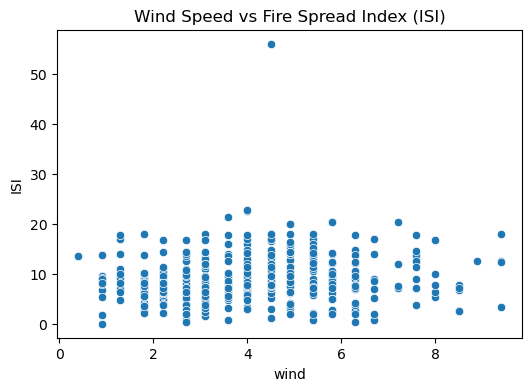

In [29]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='wind', y='ISI', data=df)
plt.title('Wind Speed vs Fire Spread Index (ISI)')
plt.show()

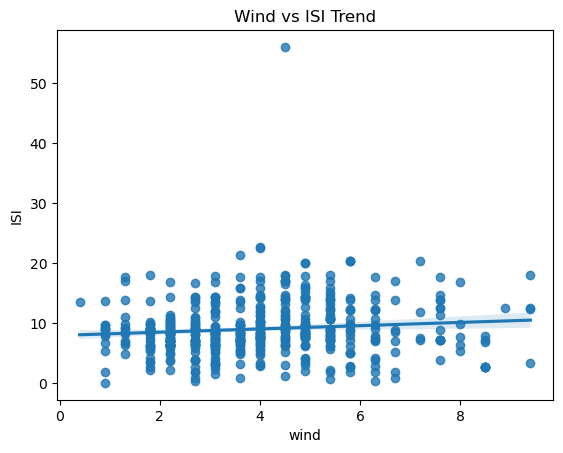

,wind,ISI
wind,1.000000,0.106826
ISI,0.106826,1.000000


In [30]:
sns.regplot(x='wind', y='ISI', data=df)
plt.title('Wind vs ISI Trend')
plt.show()

df[['wind', 'ISI']].corr()

In [6]:
results = pd.DataFrame({
    "Relationship": [
        "Temperature → FFMC",
        "Humidity → DMC",
        "Rain → DC",
        "Wind → ISI"
    ],
    "Expected Effect": [
        "Positive",
        "Negative",
        "Negative",
        "Positive"
    ]
})

results

,Relationship,Expected Effect
0,Temperature → FFMC,Positive
1,Humidity → DMC,Negative
2,Rain → DC,Negative
3,Wind → ISI,Positive


### Fire Weather Indices and Environmental Variables

This section examines how weather conditions influence the fire weather indices used to assess wildfire risk.

### Correlation Heatmap

This was used to explore relationships between environmental variables and fire indices.

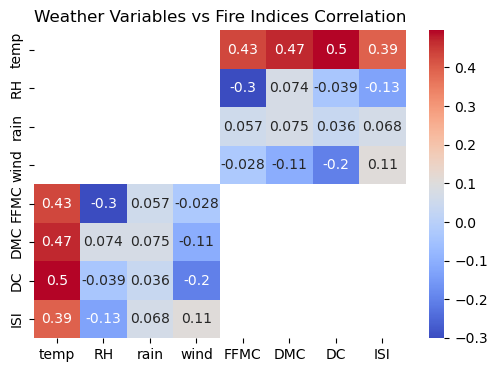

In [19]:
selected_cols = ['temp', 'RH', 'rain', 'wind', 'FFMC', 'DMC', 'DC', 'ISI']
corr = df[selected_cols].corr()
import numpy as np

weather = ['temp', 'RH', 'rain', 'wind']
indices = ['FFMC', 'DMC', 'DC', 'ISI']

mask = np.zeros_like(corr, dtype=bool)

for i in corr.index:
    for j in corr.columns:
        if (i in weather and j in weather) or (i in indices and j in indices):
            mask[corr.index.get_loc(i), corr.columns.get_loc(j)] = True

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', mask=mask)
plt.title("Weather Variables vs Fire Indices Correlation")
plt.show()

### Comparison Of Relationship Between Temperature And Fire 

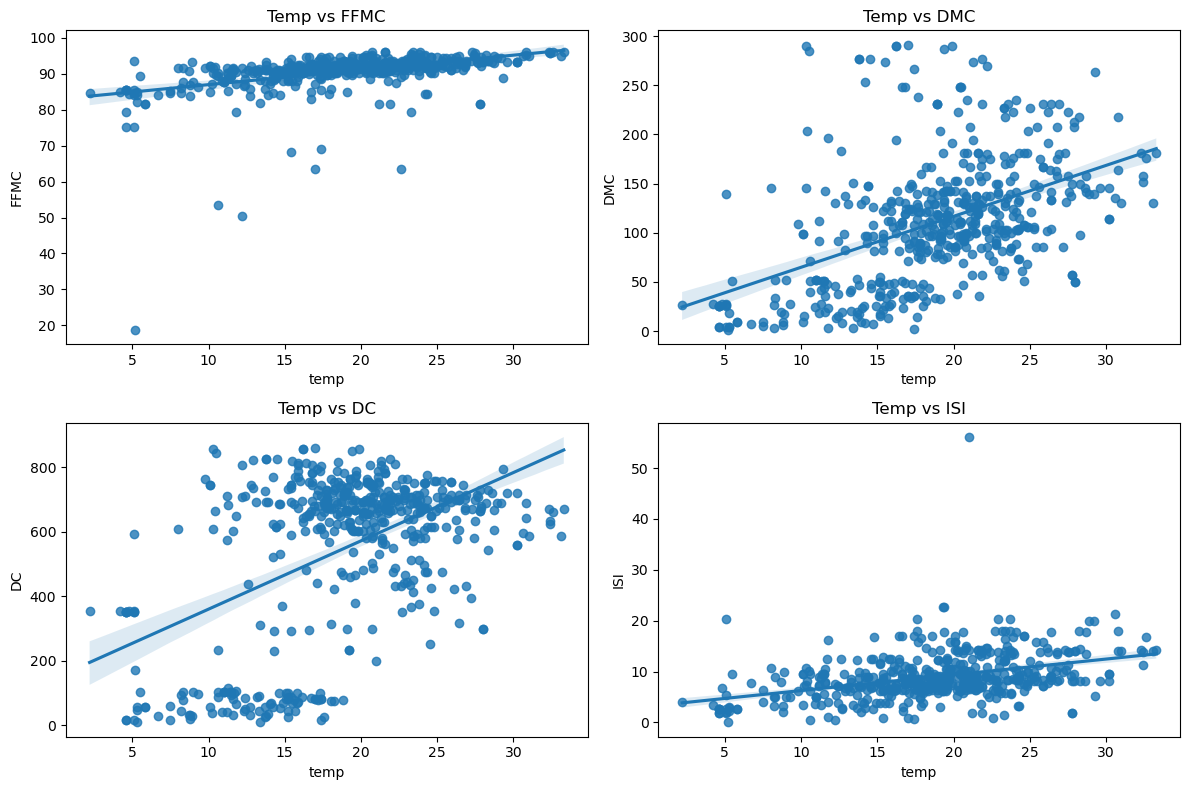

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.regplot(x='temp', y='FFMC', data=df, ax=axes[0,0])
axes[0,0].set_title('Temp vs FFMC')

sns.regplot(x='temp', y='DMC', data=df, ax=axes[0,1])
axes[0,1].set_title('Temp vs DMC')

sns.regplot(x='temp', y='DC', data=df, ax=axes[1,0])
axes[1,0].set_title('Temp vs DC')

sns.regplot(x='temp', y='ISI', data=df, ax=axes[1,1])
axes[1,1].set_title('Temp vs ISI')

plt.tight_layout()
plt.show()

This helped to see that temperature has more consistent relationships with the fire indices compared to other weather variables.  Since temperature showed the most consistent relationships, further analysis focused on Temperature vs FFMC, DMC, DC and ISI.

#### Insight 

The scatter plots show that temperature has a positive relationship with all fire weather indices. As temperature increases, FFMC, DMC, DC, and ISI generally increase. However, the strength of the relationship varies across the indices. The relationship appears strongest with FFMC and DMC, while ISI shows a weaker and more scattered pattern. This suggests that temperature plays an important role in fuel dryness and fire behaviour, especially in surface and mid-layer conditions.

### Exploring Environmental Variables Relationship With Burned Area

The goal is to identify whether these weather conditions show any visible pattern with how much land gets burned (area).

#### Temperature vs Burned Area

Are higher temperatures linked with larger wildfire burned areas?

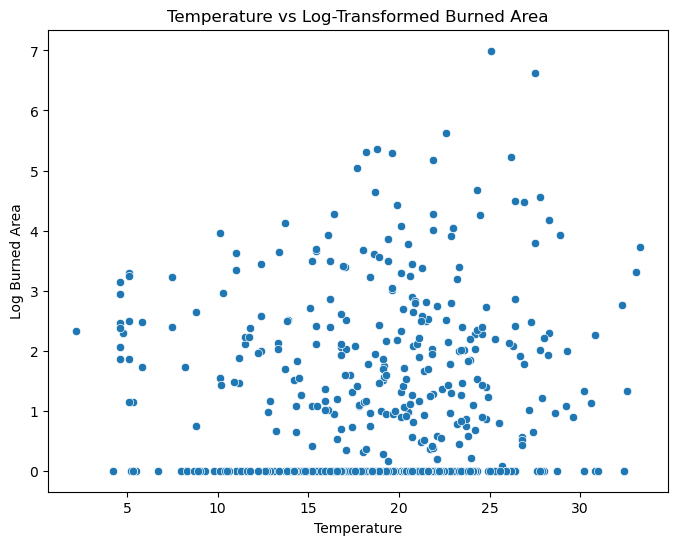

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='temp', y='area_log')
plt.title('Temperature vs Log-Transformed Burned Area')
plt.xlabel('Temperature')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot suggests a weak positive relationship between temperature and burned area. Most wildfire events are concentrated around lower burned area values, meaning many fires remained relatively small. However, a few larger wildfire events appear more often at moderate to higher temperatures, suggesting that warmer conditions may be linked to larger wildfires. 

#### Insight

This suggests that temperature may influence wildfire spread, as warmer conditions may support larger fires. The use of the log-transformed burned area also helps reduce the effect of extreme wildfire events, making the overall relationship clearer and easier to analyze.

#### Humidity vs Burned Area

Do humidity levels influence wildfire burned area?

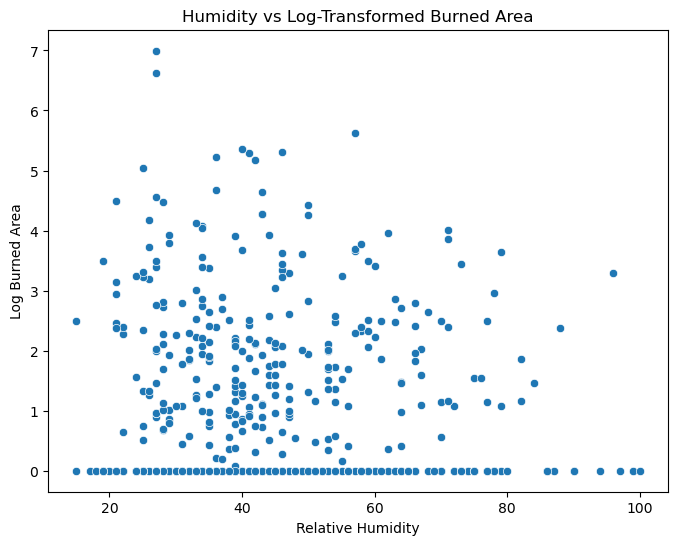

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='RH', y='area_log')
plt.title('Humidity vs Log-Transformed Burned Area')
plt.xlabel('Relative Humidity')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a slight negative relationship between humidity and burned area. Wildfire events are mostly clustered around smaller burned areas, even across different humidity levels. Still, a few larger fires appear when humidity is lower, which suggests that drier air may be linked to wider wildfire spread.

#### Insight

This suggests that humidity may influence wildfire area size, especially under drier conditions. Lower humidity can make vegetation lose moisture more easily, which may allow fires to spread faster. Although, humidity alone does not explain wildfire size, which means other factors likely also contribute to how much land gets burned. 

#### Wind vs Burned Area

Does wind speed influence wildfire burned area?

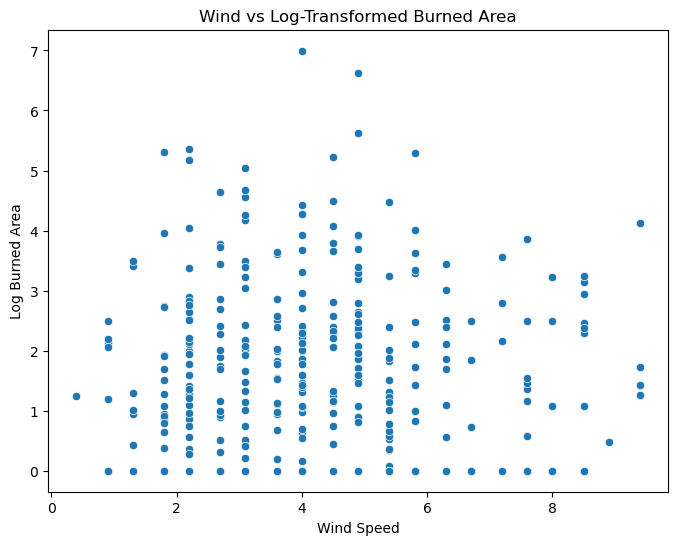

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='wind', y='area_log')
plt.title('Wind vs Log-Transformed Burned Area')
plt.xlabel('Wind Speed')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a weak relationship between wind speed and log-transformed burned area. Wildfire events are mostly clustered around lower burned area values across different wind speeds, meaning many fires remained relatively small. A few larger wildfire events appear at moderate wind speeds, which indicates that wind may support wildfire spread under certain conditions.

#### Insight

Wind speed may influence how quickly wildfires spread, especially when conditions are favorable for fire movement. However, the pattern in the chart also shows that wind alone is not enough to explain wildfire size, since many wildfire events still remained small across different wind speeds.

## Rainfall vs Burned Area

Can Rainfall influence wildfire burned area?

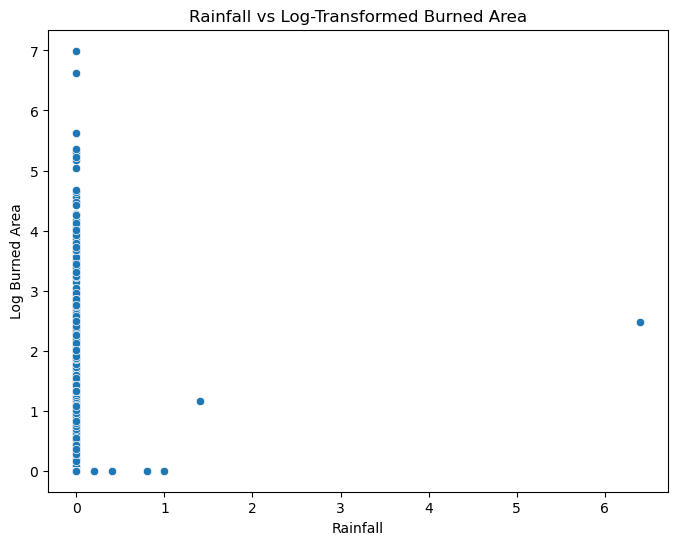

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_cleaned, x='rain', y='area_log')
plt.title('Rainfall vs Log-Transformed Burned Area')
plt.xlabel('Rainfall')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation

The scatter plot shows a very weak relationship between rainfall and log-transformed burned area. Most wildfire events occurred under little or no rainfall, while burned area values still varied across these conditions. The points are widely spread, making the relationship less clear and showing that rainfall alone does not strongly explain wildfire burned area in the dataset.

#### Insight

Most wildfire events in the dataset happened during low rainfall conditions. However, both small and larger wildfire events still occurred when rainfall was low, which shows that rainfall alone is not enough to explain wildfire burned area. Other environmental factors likely also affect how much land gets burned.

### Fire Weather Indices Overview On Burned Area

#### Comparison of Fire Weather Conditions

To better understand the records with zero burned area, fire weather conditions were compared between observations with no burned area and those with recorded burned area. This helps to check whether both groups were exposed to similar environmental conditions and whether the zero values are meaningful for further analysis.

The fire weather indices (FFMC, DMC, DC, and ISI) describe how favorable the conditions are for fire ignition and spread, regardless of the final burned area.

In [9]:
indices = ['FFMC', 'DMC', 'DC', 'ISI']

comparison = df.groupby(df['area'] == 0)[indices].mean()
comparison.index = ['Non-Zero Area', 'Zero Area']

comparison

,FFMC,DMC,DC,ISI
Non-Zero Area,91.034074,114.707778,570.867037,9.177037
Zero Area,90.219028,106.679757,522.878138,8.851822


Fire weather indices were compared between zero burned area records and non-zero burned area records.

The results show that both groups have similar values, although the non-zero burned area group is slightly higher across most indices. This suggests that fires with and without burned area often occur under similar weather conditions.

Overall, this supports keeping the zero burned area records in the dataset, since they still occur under similar fire weather conditions 

## Distribution Comparison of Fire Weather Indices

Boxplots was used to visually compare fire weather conditions between zero and non-zero burned area events.

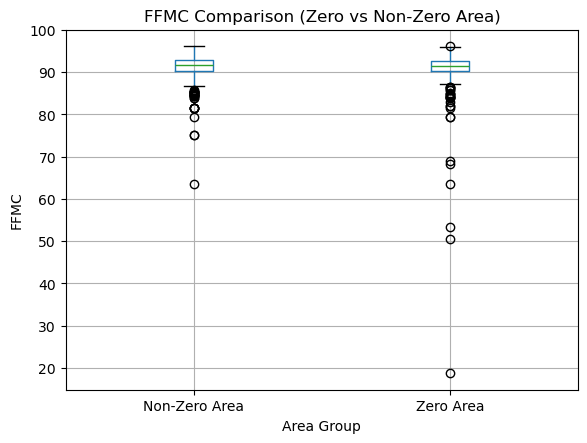

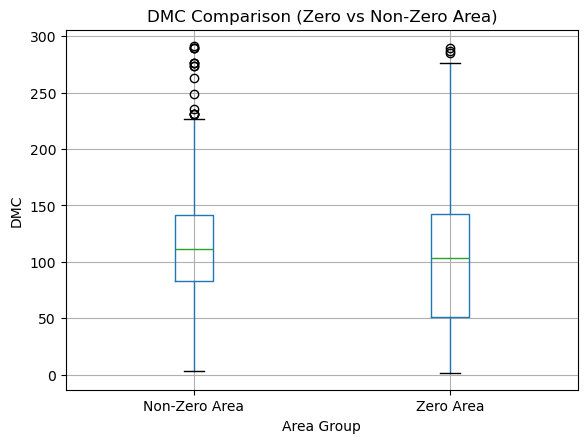

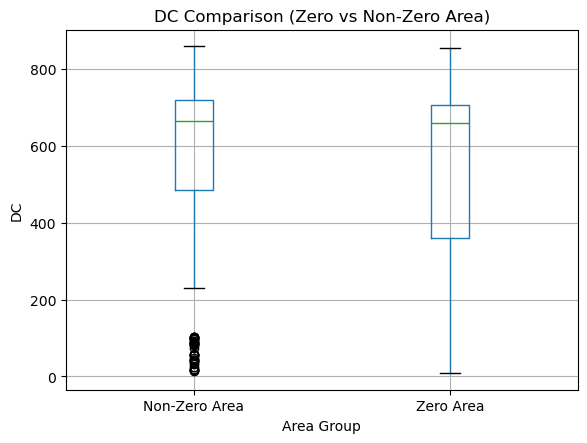

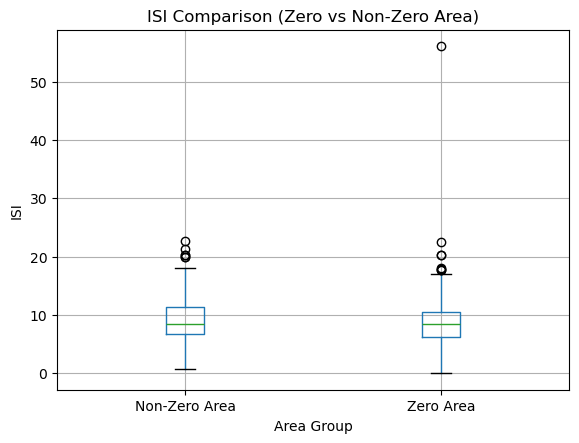

In [10]:
# creating grouping column
df['area_group'] = df['area'].apply(lambda x: 'Zero Area' if x == 0 else 'Non-Zero Area')

import matplotlib.pyplot as plt

for col in indices:
    df.boxplot(column=col, by='area_group')
    plt.title(f'{col} Comparison (Zero vs Non-Zero Area)')
    plt.suptitle("")
    plt.xlabel("Area Group")
    plt.ylabel(col)
    plt.show()

## Seasonal Wildfire Trend 

Wildfire timing patterns will be checked by examining wildfire frequency across months and days, as well as burned area trends by month. This helps identify possible seasonal patterns in wildfire activity.

#### Fires by Month

Which month recorded the highest number of wildfire events?

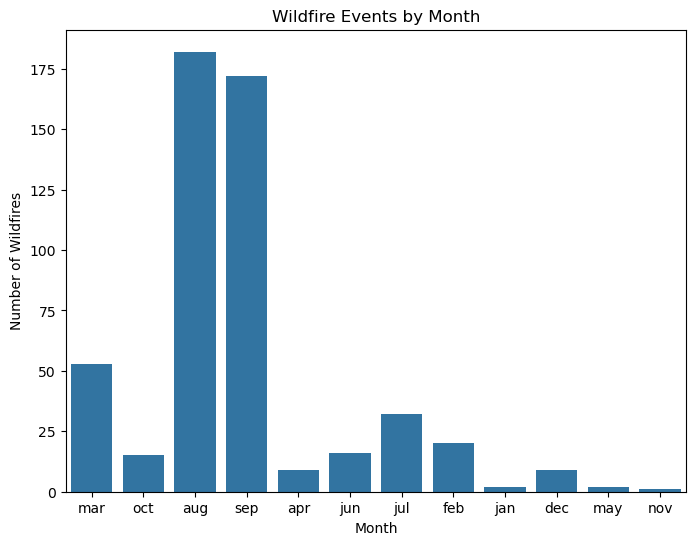

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='month')
plt.title('Wildfire Events by Month')
plt.xlabel('Month')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart above shows that wildfire events were not evenly distributed across the months. August and September recorded the highest number of wildfire events, while some months such as November, May, and January recorded very few wildfire occurrences. This pattern indicates that wildfire activity was more concentrated during certain periods of the year.

#### Insight

This indicates that wildfire activity may increase during specific seasons, particularly around late summer periods such as August and September. Environmental conditions during these months, such as higher temperatures and drier conditions, may contribute to increased wildfire occurrence.

### Fires by Day

What days recorded more wildfire events?

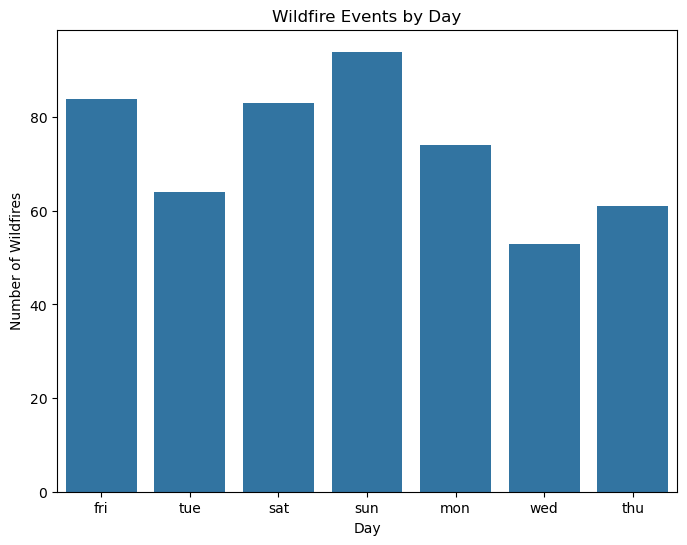

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.countplot(data=df_cleaned, x='day')
plt.title('Wildfire Events by Day')
plt.xlabel('Day')
plt.ylabel('Number of Wildfires')
plt.show()

#### Interpretation

The chart shows variations in wildfire frequency across different days of the week. Sunday recorded the highest number of wildfire events, while Wednesday recorded the lowest. Although wildfire events occurred throughout the week, some days experienced slightly higher wildfire activity than others.

#### Insight

This indicates that wildfire occurrences may vary across the week, but the differences are not extremely large. The pattern suggests that wildfire activity is not strongly concentrated on a single day, as wildfire events were recorded consistently throughout the week.

#### Wildfire Severity by Month

What month experienced larger wildfire burned areas?

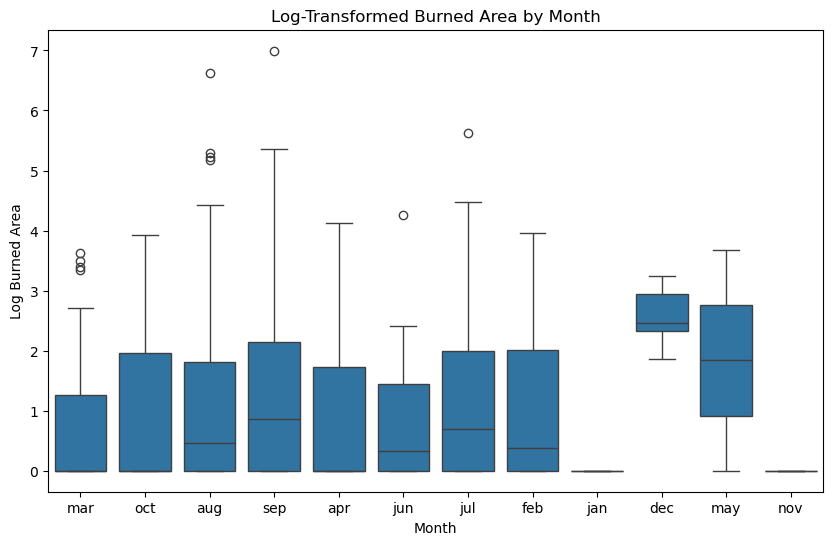

In [53]:
import matplotlib.pyplot as lt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.boxplot(data=df_cleaned, x='month', y='area_log')
plt.title('Log-Transformed Burned Area by Month')
plt.xlabel('Month')
plt.ylabel('Log Burned Area')
plt.show()

#### Interpretation
The box plot shows differences in log-transformed burned area across the months. Months such as September, July, and August recorded higher burned area values and greater variation compared to some other months. December also shows relatively higher median burned area values, although with fewer extreme values. In contrast, months like January and November recorded little or no burned area activity. The presence of outliers in some months indicates that a few wildfire events resulted in unusually large burned areas.

#### Insight

This indicates that wildfire severity varied across different months of the year. Months with higher burned area values and wider distributions may have experienced environmental conditions that supported larger wildfire spread. 

## Importance of Fire Weather Indices

In [18]:
df_cleaned[
    ["FFMC","DMC","DC","ISI","area_log"]
].corr()

,FFMC,DMC,DC,ISI,area_log
FFMC,1.000000,0.382619,0.330512,0.531805,0.046799
DMC,0.382619,1.000000,0.682192,0.305128,0.067153
DC,0.330512,0.682192,1.000000,0.229154,0.066360
ISI,0.531805,0.305128,0.229154,1.000000,-0.010347
area_log,0.046799,0.067153,0.066360,-0.010347,1.000000


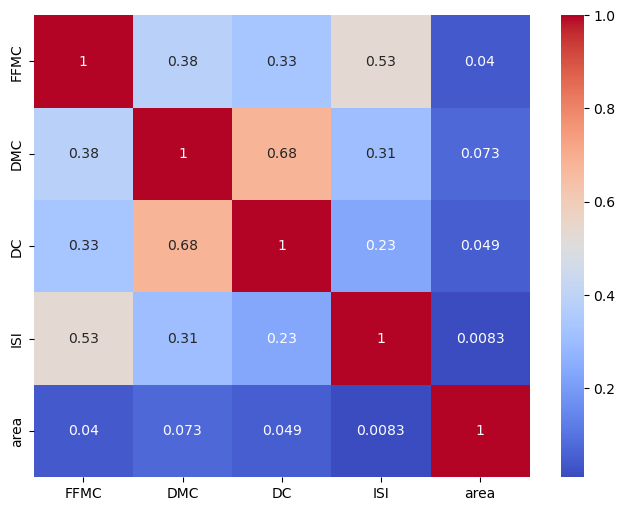

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_cleaned[
        ["FFMC","DMC","DC","ISI","area"]
    ].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Interpretation

The heatmap shows that all fire weather indices have a positive but weak relationship with burned area. This means that as the index values increase, the burned area may also increase slightly. Among the four indices, DMC has the highest correlation (0.073), making it the most related to wildfire severity in this dataset. However, the relationship is still weak, which suggests that wildfire severity is not caused by one fire index alone but by a combination of different factors such as weather conditions and fire behaviour.

##  FEATURE ENGINEERING (Creating New Variables)

Feature engineering was carried out to create new variables that can help improve wildfire risk analysis and make patterns in the data easier to understand. The new features were created from existing weather and wildfire variables to help identify conditions linked to wildfire risk and fire severity.

### High Risk Condition Flag

This variable was created to identify weather conditions that may increase the chances of wildfire occurrence.

In [23]:
# Wildfire occurence is high risk if:
df_cleaned["high_risk"] = (
    (df_cleaned["temp"] >= 28) &
    (df_cleaned["wind"] >= 4) &
    (df_cleaned["RH"] <= 45))
df_cleaned[["temp", "wind", "RH", "high_risk"]].head()

,temp,wind,RH,high_risk
0,8.2,6.7,51,False
1,18.0,0.9,33,False
2,14.6,1.3,33,False
3,8.3,4.0,97,False
4,11.4,1.8,99,False


The high-risk wildfire condition feature was created using weather thresholds associated with Mediterranean wildfire behavior in Portugal.

A condition is classified as high risk when:
- temperature was at least 28°C and above,
- wind speed was at least 4 km/h and above,
- relative humidity was 45% or lower.

These thresholds were selected because hot temperatures, stronger winds, and low humidity can dry out vegetation and make wildfire spread more likely.

In [24]:
# High Risk Condtion Distribution

df_cleaned["high_risk"].value_counts()

high_risk
False    504
True      13
Name: count, dtype: int64

#### Interpretation
The distribution of the high-risk feature shows that most wildfire observations were classified as low risk, while only a small number met the high-risk condition criteria.

Out of 517 observations:
- 504 were classified as low risk
- 13 were classified as high risk

#### Insight
This suggests that extreme wildfire weather conditions were not very common in the dataset.

### Fire Size Category
This was created to group wildfire incidents into small and large fire categories based on the burned area. The median burned area was used as the classification threshold because the burned area data is highly skewed.

This feature improves interpretability by simplifying wildfire severity into meaningful categories that can be analyzed more easily.

In [25]:
# use of median because of the skewedness of the dataset
median_area = df_cleaned["area"].median()

In [26]:
# Fire Size Category of dataset
df_cleaned["fire_size"] = df_cleaned["area"].apply(
    lambda x: "Large Fire" if x > median_area else "Small Fire")
df_cleaned [["area", "fire_size"]].head()

,area,fire_size
0,0.0,Small Fire
1,0.0,Small Fire
2,0.0,Small Fire
3,0.0,Small Fire
4,0.0,Small Fire


In [27]:
# Fire Size Condtion Distribution

df_cleaned["fire_size"].value_counts()

fire_size
Small Fire    259
Large Fire    258
Name: count, dtype: int64

### Interpretation
Out of 517 observations:
- 259 were classified as Small Fire
- 258 were classified as Large Fire

This balanced distribution occurred because the median burned area was used as the classification threshold. 

### Insight
The result shows that the feature created a clear separation between small and large fires, making wildfire severity easier to analyse.

### Feature Engineering Summary

Two new features were created during this stage:
- High_risk → identifies weather conditions linked to wildfire risk
- Fire_size → groups wildfire incidents into small and large fires

These features help improve wildfire interpretation and can support future predictive modelling.

In [28]:
# Saving Updated Dataset With The newly created features

df_cleaned.to_csv("df_cleaned.csv", index=False)

## High-Risk Threshold Analysis

This section identifies the environmental and fire danger conditions under which larger wildfire events are more likely to occur. The aim is to establish practical threshold ranges that can support wildfire monitoring and early warning systems.

In [55]:
# High-risk temperature range
df_cleaned.groupby("fire_size")["temp"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,258.0,19.262791,6.286705,2.2,15.95,20.1,23.40,33.3
Small Fire,259.0,18.516988,5.271212,4.2,15.40,18.7,21.75,32.4


In [56]:
# High-risk humidity range
df_cleaned.groupby("fire_size")["RH"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,258.0,43.569767,15.262584,15.0,32.25,41.0,53.0,96.0
Small Fire,259.0,45.003861,17.304500,15.0,33.00,42.0,54.0,100.0


In [57]:
# High-risk wind range
df_cleaned.groupby("fire_size")["wind"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,258.0,4.141473,1.904517,0.4,2.7,4.0,4.90,9.4
Small Fire,259.0,3.894208,1.666219,0.9,2.7,3.6,5.15,8.5


In [58]:
# High-risk drought code
df_cleaned.groupby("fire_size")["DC"].describe()

,count,mean,std,min,25%,50%,75%,max
fire_size,,,,,,,,
Large Fire,258.0,566.685659,233.206354,15.3,476.375,664.35,721.325,860.6
Small Fire,259.0,529.266795,261.147129,7.9,372.450,661.80,706.650,855.3


### Practical Insight

The threshold analysis helps identify specific weather conditions that may signal increased wildfire risk. The analysis shows that larger wildfire events were more common under specific environmental conditions.

- **Temperature:** Large fires had an average temperature of **19.3°C**, with most occurring between **15.9°C and 23.4°C**. This suggests wildfire risk tends to increase when temperatures rise above **20°C**.

- **Relative Humidity (RH):** Large fires had an average humidity of **43.6%**, with many occurring when humidity dropped between **32% and 41%**. This indicates that lower humidity creates drier fuel conditions that support wildfire spread.

- **Wind Speed:** Large fires recorded an average wind speed of **4.1 km/h**, with many severe events happening between **4.0 and 4.9 km/h**. This suggests stronger winds may contribute to faster fire spread.

- **Drought Code (DC):** Large fires had an average DC value of **566.7**, with most severe fires occurring between **476 and 721**. This shows that prolonged dry conditions increase wildfire severity.

These conditions can be monitored through meteorological stations to improve early detection and response planning. 

#### Why These Variables Were Selected for Threshold Analysis

The threshold analysis focused on temperature, relative humidity, wind speed, and drought code because these variables showed the strongest relevance to wildfire severity during the exploratory analysis.

Temperature, humidity, and wind are direct environmental factors that influence fire ignition and spread, while drought code represents long-term dryness conditions. These variables also provide practical value because they can be monitored in real time through meteorological stations for wildfire risk assessment.

## MODELLING PREPARATION

In this section, the cleaned dataset was prepared for modelling. The target variable and feature columns were selected,and the data was split into training and testing sets.

In [29]:
# loading Cleaned Dataset new columns created inclusive

import pandas as pd
df_cleaned.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,area_group,area_log,high_risk,fire_size
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,Zero Area,0.0,False,Small Fire
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,Zero Area,0.0,False,Small Fire
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,Zero Area,0.0,False,Small Fire
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,Zero Area,0.0,False,Small Fire
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,Zero Area,0.0,False,Small Fire


In [30]:
# Defining the Target Variable for the model
y = df_cleaned["fire_size"]

In [67]:
# Removing area, area_log columns,area_group, fire_size as it is the target variable to prevent data leakage during modeling

X = df_cleaned.drop(["area", "area_log","area_group", "fire_size"], axis=1)

In [44]:
#checking dataset for text object

X.dtypes

X              int64
Y              int64
month         object
day           object
FFMC         float64
DMC          float64
DC           float64
ISI          float64
temp         float64
RH             int64
wind         float64
rain         float64
high_risk       bool
dtype: object

In [45]:
# Converting text to Numbers By Encoding Categorical Variables

X = pd.get_dummies(X, drop_first=True)

#### Train_Test Split

The dataset was divided into training and testing sets. 
80% of the data was used for training the model, while 20% was reserved for testing.

In [46]:
# Spliting dataset into training data and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

#### Checking Dataset Shape

The shapes of the training and testing datasets were checked to confirm that the data was split correctly.

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (413, 28)
X_test shape: (104, 28)
y_train shape: (413,)
y_test shape: (104,)


### Modelling Preparation Summary

The dataset was prepared for machine learning by defining the feature and target variables and splitting the data into training and testing sets.

The output shows that the dataset was successfully divided into training and testing sets. The training data contains 413 rows, while the testing data contains 104 rows. Both datasets contain 28 feature columns for modelling.

## MODELLING PHASE

In [48]:
# Importing libraries

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import numpy as np

### Building The Model

In [49]:
# Traing the Model

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Predict Wildfire_Size Category

In [50]:
y_pred = model.predict(X_test)

### Evaluation Of Model

In [51]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))

Accuracy: 0.5576923076923077
              precision    recall  f1-score   support

  Large Fire       0.54      0.63      0.58        51
  Small Fire       0.58      0.49      0.53        53

    accuracy                           0.56       104
   macro avg       0.56      0.56      0.56       104
weighted avg       0.56      0.56      0.56       104



### Model Evaluation Interpretation

The Decision Tree Classification model was used to predict whether a wildfire would be classified as a Small Fire or Large Fire based on environmental and weather conditions.

The model achieved an accuracy of 56%, which means it correctly predicted wildfire size in about half of the test cases. This shows that the model has moderate performance but still has room for improvement.

For **Large Fire**, the model had a precision of 54% and a recall of 63%. This means it was better at identifying large fires compared to small fires.

For **Small Fire**, the model had a precision of 58% and a recall of 49%, meaning it struggled more to correctly identify small fires.

The F1-scores for both classes were close (0.58 for Large Fire and 0.53 for Small Fire), showing that the model’s performance is fairly balanced across both categories.

Overall, the results suggest that wildfire size prediction is influenced by many factors, making it a challenging problem for the model to classify accurately.

## Model Performance

The Decision Tree model achieved an accuracy of **56%**, meaning it correctly classified wildfire size in a little over half of the test cases. 

The model performed slightly better in identifying **Large Fires** with a recall of **63%**, compared to **Small Fires** with a recall of **49%**. This suggests that the model was more effective at detecting larger wildfire events.

The F1-scores for both classes were relatively close, showing that the model had a fairly balanced performance across the two categories.

Overall, the model shows moderate predictive ability, but the results indicate that wildfire severity is influenced by multiple factors, making prediction more complex. Further model improvement or testing with more advanced algorithms may help improve performance.

### Feature Importance Analysis

Feature importance was examined to identify the variables that contributed most to wildfire size prediction.

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
7,RH,0.153523
6,temp,0.149473
4,DC,0.111950
8,wind,0.108653
5,ISI,0.101027
0,X,0.083241
1,Y,0.078972
3,DMC,0.068219
2,FFMC,0.063190
24,day_sun,0.042174


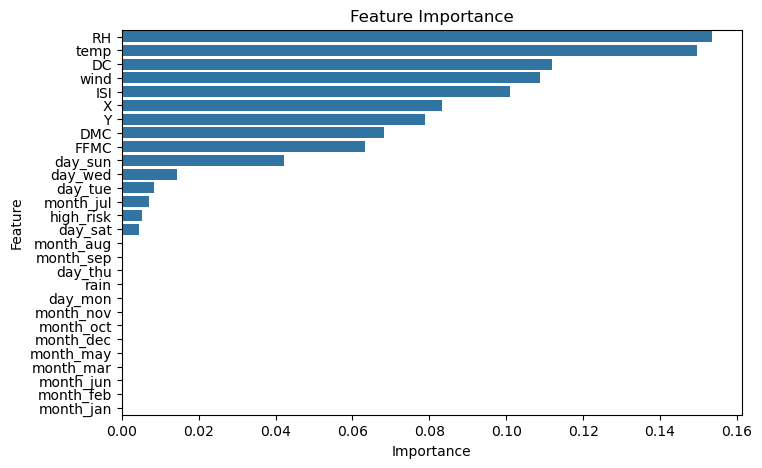

In [54]:
# plotting the feature variable according to their level of importance                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()

### Feature Importance Interpretation

The feature importance analysis shows that **Relative Humidity (RH)** is the most important factor in predicting wildfire size, followed by **temperature**, **Drought Code (DC)**, and **wind speed**. This suggests that weather conditions play a major role in wildfire severity.

Among the fire weather indices, **DC** has the highest importance, followed by **ISI**, **DMC**, and **FFMC**. This indicates that long-term dryness and fire spread conditions contribute significantly to wildfire behavior.

The results show that both environmental factors and fire weather indices are important in wildfire prediction, but environmental variables such as humidity and temperature appear to have stronger influence in this model.

This is a strong result because it follows wildfire behavior in real life. Lower humidity means the fuel becomes drier, higher temperatures can lead to faster ignition, higher drought code shows longer dry periods, and stronger wind can increase the speed at which fire spreads.

Overall, the model suggests that wildfire severity is influenced by a combination of dryness, heat, wind conditions, and fire danger indicators rather than a single factor.

# KEY INSIGHTS

**1. Temperature and low humidity were strongly linked to wildfire severity:**
The analysis showed that larger wildfire events occurred under hotter and drier conditions. Large fires had an average temperature of **19.3°C**, with most occurring between **15.9°C and 23.4°C**, while humidity was lower, averaging **43.6%**, with many severe fires happening between **32% and 41%**. This confirms that dry and warm weather creates favorable conditions for wildfire ignition and spread.

**2. Long-term dryness played a major role in wildfire behaviour:**
Among the fire weather indices, **Drought Code (DC)** had the highest importance in the model. Large fires recorded an average DC value of **566.7**, with most severe events occurring between **476 and 721**, showing that prolonged dry conditions significantly increase wildfire severity.

**3. DMC showed the strongest direct relationship with burned area:**
Although the correlations between fire weather indices and burned area were generally weak, **DMC** recorded the highest correlation among the fire indices. This suggests that medium-term dryness conditions have some influence on wildfire severity.

**4. Wind speed contributed to wildfire spread:**
The feature importance analysis showed that wind speed was one of the strongest predictors of wildfire severity. Large fires had an average wind speed of **4.1 km/h**, with many severe fire events occurring between **4.0 and 4.9 km/h**, indicating that stronger winds can support faster fire spread.

**5. Rainfall had little influence on wildfire severity:**
Most wildfire observations recorded little or no rainfall, and rainfall contributed less compared to other environmental variables in the model. This suggests that rainfall had limited influence on reducing fire severity within this dataset.

**6. Wildfire activity was higher during August and September:**
The monthly wildfire analysis revealed that August and September recorded the highest wildfire activity and larger burned areas, indicating that wildfire risk increases during hotter and drier seasons.

**7. Wildfire severity is influenced by multiple interacting factors:**
Both the correlation analysis and feature importance results showed that wildfire severity cannot be explained by a single variable. Instead, it is shaped by the combined effects of temperature, humidity, wind, dryness, and fire danger indicators.

**8. Wildfire behaviour remains difficult to predict:**
The Decision Tree model achieved an accuracy of **56%**, showing moderate predictive performance. While the model captured some wildfire patterns, the result suggests that wildfire severity is influenced by several interacting environmental and geographical factors that may not have been fully captured in the dataset.

# Recommedndations

**1. Strengthen wildfire monitoring with automated alert systems**
Forest managers and environmental specialists should improve wildfire monitoring by using meteorological stations equipped with automated alert systems. These systems can trigger warnings when critical conditions are reached, such as temperatures above 20°C, relative humidity below 40%, wind speed above 4 km/h, or Drought Code (DC) above 500. This helps reduce human oversight and supports faster preventive action.

**2. Increase fuel management in high drought periods**
Since long-term dryness was strongly linked to wildfire severity, forest managers should regularly clear dry leaves, dead trees, and excess vegetation during prolonged dry periods to reduce fuel build-up and lower fire intensity.

**3. Increase patrol and preparedness during peak wildfire months**
Since wildfire activity was higher in August and September, forest management teams should intensify surveillance, emergency readiness, and fire prevention campaigns during these periods.

**4. Monitor long-term dryness conditions closely**
The analysis showed that higher Drought Code (DC) values were strongly linked to wildfire severity. Environmental agencies should track prolonged dry periods as part of wildfire risk assessment.

**5. Improve rapid response systems during windy conditions**
Because stronger winds were associated with wildfire spread, emergency response teams should be placed on higher alert during periods of increased wind speed to reduce fire expansion.

**6. Use predictive models as an early warning support tool**
Although the model had moderate performance, it was able to identify useful wildfire patterns. Forest managers can use such models alongside weather monitoring systems to help predict wildfire risk early. Including extra information like vegetation type and land conditions may improve prediction accuracy.

**7. Promote wildfire prevention education in local communities**
Communities living near forest areas in Portugal should be educated on practical wildfire prevention measures, especially during the high-risk summer months. This includes safe agricultural burning practices, proper handling of campfires and barbecues, avoiding the disposal of cigarette butts in dry vegetation, reducing the use of spark-producing machinery during hot and dry conditions, and encouraged to report smoke or fire outbreaks early. Public understanding of high-risk weather conditions such as high temperatures, low humidity, and strong winds can also improve wildfire prevention efforts.


# Conclusion

This project showed that wildfire severity is mainly affected by weather conditions and fire danger indicators. From the analysis, it was observed that higher temperature, lower humidity, stronger wind, and long dry periods increase the chances of larger wildfires.

The study also showed that wildfire activities were more common in August and September, which were the hotter and drier months. This suggests that season plays an important role in wildfire occurrence.

The model was able to identify some wildfire patterns, but its performance was moderate, showing that wildfire behaviour is not easy to predict because many factors can affect it.

Overall, the analysis helped to understand the major conditions that contribute to wildfire severity. These findings can help forest managers and environmental specialists improve wildfire monitoring, early detection, and prevention in Portugal.